# Análisis Comparativo de Implementaciones HMM Multi-lenguaje

## Resumen Académico

Este trabajo presenta un **estudio comparativo de rendimiento** entre implementaciones de Modelos Ocultos de Markov (HMM) en tres paradigmas de programación distintos:

### Objetivos
1. **Implementar algoritmos HMM** (Forward y Viterbi) en C++, Python y Julia
2. **Evaluar rendimiento computacional** entre lenguajes compilados vs interpretados
3. **Verificar consistencia numérica** entre implementaciones
4. **Analizar secuencias de ADN** usando estados ocultos H/L (High/Low)

### Metodología
- **C++ con SWIG**: Implementación optimizada compilada con interfaz Python
- **Python puro**: Implementación nativa usando NumPy para álgebra lineal
- **Julia con PyJulia**: Código Julia ejecutado desde Python aprovechando JIT

### Aplicación Bioinformática
Modelo HMM para análisis de secuencias de ADN con:
- **Estados ocultos**: H (High GC content), L (Low GC content)
- **Observaciones**: Bases nucleotídicas A, C, G, T
- **Algoritmos**: Forward (probabilidad de secuencia), Viterbi (secuencia de estados más probable)

### Estructura del Notebook
1. **Configuración de entorno** y compilación C++
2. **Implementaciones HMM** en los tres lenguajes
3. **Análisis comparativo** de rendimiento y precisión
4. **Visualizaciones** y benchmarks extensivos

# **Creacion del entorno swig**

### Borra todos esos archivos y carpetas si existen en el directorio actual.

In [ ]:
!rm -f *.cxx *.h *.i *.o *.so *.py __pycache__ -rf
print("Entorno limpiado")

Entorno limpiado


### Instala SWIG (herramienta para generar interfaces entre C/C++ y otros lenguajes).

In [ ]:
!apt-get install swig -y
print("SWIG instalado")

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  swig4.0
Suggested packages:
  swig-doc swig-examples swig4.0-examples swig4.0-doc
The following NEW packages will be installed:
  swig swig4.0
0 upgraded, 2 newly installed, 0 to remove and 35 not upgraded.
Need to get 1,116 kB of archives.
After this operation, 5,542 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 swig4.0 amd64 4.0.2-1ubuntu1 [1,110 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 swig all 4.0.2-1ubuntu1 [5,632 B]
Fetched 1,116 kB in 1s (831 kB/s)
Selecting previously unselected package swig4.0.
(Reading database ... 126435 files and directories currently installed.)
Preparing to unpack .../swig4.0_4.0.2-1ubuntu1_amd64.deb ...
Unpacking swig4.0 (4.0.2-1ubuntu1) ...
Selecting previously unselected package swig.
Preparing to unpack .../swig_4.0.2-1ubunt

### %%file hmm.h → guarda el contenido siguiente en un archivo llamado hmm.h.

Define la clase HMM en C++ para representar un modelo oculto de Markov:

Matrices privadas: transición (transition_matrix), emisión (emission_matrix) y probabilidades iniciales (initial_probs).

Métodos públicos:

Constructor para inicializar el modelo.

forward_algorithm → calcula la probabilidad de una secuencia de observaciones.

viterbi_algorithm → encuentra la secuencia de estados más probable.

Métodos auxiliares para obtener número de estados y observaciones.

In [ ]:
%%file hmm.h
/* File : hmm.h */
#ifndef HMM_H
#define HMM_H

#include <vector>

class HMM {
private:
    std::vector<std::vector<double>> transition_matrix;
    std::vector<std::vector<double>> emission_matrix;
    std::vector<double> initial_probs;
    int num_states;
    int num_observations;

public:
    HMM(const std::vector<std::vector<double>>& trans_matrix,
        const std::vector<std::vector<double>>& emis_matrix,
        const std::vector<double>& init_probs);

    // Forward algorithm
    double forward_algorithm(const std::vector<int>& observations);

    // Viterbi algorithm
    std::vector<int> viterbi_algorithm(const std::vector<int>& observations);

    // Helper methods
    int get_num_states() const { return num_states; }
    int get_num_observations() const { return num_observations; }
};

#endif

Writing hmm.h


### Ese código guarda la implementación de la clase HMM en el archivo hmm.cxx y hace lo siguiente:

Constructor → inicializa matrices de transición, emisión y probabilidades iniciales; también guarda el número de estados y observaciones.

forward_algorithm → implementa el algoritmo Forward para calcular la probabilidad total de una secuencia de observaciones.

viterbi_algorithm → implementa el algoritmo de Viterbi para encontrar la secuencia más probable de estados ocultos que genera las observaciones.

In [ ]:
%%file hmm.cxx
/* File : hmm.cxx */
#include "hmm.h"
#include <algorithm>
#include <cmath>

HMM::HMM(const std::vector<std::vector<double>>& trans_matrix,
         const std::vector<std::vector<double>>& emis_matrix,
         const std::vector<double>& init_probs)
    : transition_matrix(trans_matrix), emission_matrix(emis_matrix),
      initial_probs(init_probs) {
    num_states = trans_matrix.size();
    num_observations = emis_matrix[0].size();
}

double HMM::forward_algorithm(const std::vector<int>& observations) {
    int T = observations.size();
    std::vector<std::vector<double>> alpha(T, std::vector<double>(num_states));

    // Inicialización
    for (int i = 0; i < num_states; i++) {
        alpha[0][i] = initial_probs[i] * emission_matrix[i][observations[0]];
    }

    // Recursión
    for (int t = 1; t < T; t++) {
        for (int j = 0; j < num_states; j++) {
            alpha[t][j] = 0.0;
            for (int i = 0; i < num_states; i++) {
                alpha[t][j] += alpha[t-1][i] * transition_matrix[i][j];
            }
            alpha[t][j] *= emission_matrix[j][observations[t]];
        }
    }

    // Terminación
    double prob = 0.0;
    for (int i = 0; i < num_states; i++) {
        prob += alpha[T-1][i];
    }

    return prob;
}

std::vector<int> HMM::viterbi_algorithm(const std::vector<int>& observations) {
    int T = observations.size();
    std::vector<std::vector<double>> delta(T, std::vector<double>(num_states));
    std::vector<std::vector<int>> psi(T, std::vector<int>(num_states));

    // Inicialización
    for (int i = 0; i < num_states; i++) {
        delta[0][i] = initial_probs[i] * emission_matrix[i][observations[0]];
        psi[0][i] = 0;
    }

    // Recursión
    for (int t = 1; t < T; t++) {
        for (int j = 0; j < num_states; j++) {
            delta[t][j] = 0.0;
            psi[t][j] = 0;

            for (int i = 0; i < num_states; i++) {
                double temp = delta[t-1][i] * transition_matrix[i][j];
                if (temp > delta[t][j]) {
                    delta[t][j] = temp;
                    psi[t][j] = i;
                }
            }
            delta[t][j] *= emission_matrix[j][observations[t]];
        }
    }

    // Terminación
    std::vector<int> path(T);
    double max_prob = 0.0;
    for (int i = 0; i < num_states; i++) {
        if (delta[T-1][i] > max_prob) {
            max_prob = delta[T-1][i];
            path[T-1] = i;
        }
    }

    // Backtracking
    for (int t = T-2; t >= 0; t--) {
        path[t] = psi[t+1][path[t+1]];
    }

    return path;
}


Writing hmm.cxx


### Ese bloque crea el archivo hmm.i, que sirve como interfaz para SWIG y hace esto:

%module hmm → define que el módulo generado se llamará hmm (lo que permitirá usar la clase HMM desde Python).

El bloque %{ #include "hmm.h" %} → inserta el encabezado de C++ en el wrapper.

%include "std_vector.i" → habilita compatibilidad de std::vector con Python.

En el namespace std se crean plantillas (%template) para exponer a Python:

IntVector → std::vector<int>

DoubleVector → std::vector<double>

DoubleMatrix → std::vector<std::vector<double>>

%include "hmm.h" → expone la clase HMM definida en tu header para que Python pueda usarla.

In [ ]:
%%file hmm.i
%module hmm

%{
#include "hmm.h"
%}

%include "std_vector.i"

namespace std {
    %template(IntVector) vector<int>;
    %template(DoubleVector) vector<double>;
    %template(DoubleMatrix) vector<vector<double>>;
}

%include "hmm.h"



Writing hmm.i


### Ese bloque de código hace todo el pipeline de compilación con SWIG para poder usar tu clase HMM de C++ en Python:

!swig -c++ -python ./hmm.i → genera el wrapper hmm_wrap.cxx y hmm.py a partir del archivo de interfaz hmm.i.

!g++ -O2 -fPIC -c hmm.cxx → compila la implementación de la clase HMM a un objeto (hmm.o).

!g++ -O2 -fPIC -c hmm_wrap.cxx -I/usr/include/python3.10 → compila el wrapper de SWIG (hmm_wrap.o), enlazándolo con Python 3.10.

!g++ -shared hmm.o hmm_wrap.o -o _hmm.so → crea la librería compartida _hmm.so, que es la que Python carga.


In [ ]:
# Generar wrapper de Python con SWIG
!swig -c++ -python ./hmm.i

# Compilar el código C++
!g++ -O2 -fPIC -c hmm.cxx

# Compilar el wrapper generado por SWIG
!g++ -O2 -fPIC -c hmm_wrap.cxx -I/usr/include/python3.10

# Crear la librería dinámica
!g++ -shared hmm.o hmm_wrap.o -o _hmm.so

print("Librería HMM compilada exitosamente")

Librería HMM compilada exitosamente


# **Creacion Entorno Python**

### Ese código define una clase HMMPython en puro Python/NumPy que replica lo que se hizo en C++/SWIG.

Constructor (__init__)

Recibe matrices de transición, emisión y probabilidades iniciales.

Calcula el número de estados (N) y observaciones (M).

forward_algorithm

Implementa el algoritmo Forward.

Calcula la probabilidad total de observar una secuencia dada el modelo (P(O|λ)).

viterbi_algorithm

Implementa el algoritmo de Viterbi.

Encuentra la secuencia de estados ocultos más probable que generó las observaciones.

In [ ]:
import numpy as np

class HMMPython:
    """
    Implementación de Modelo Oculto de Markov en Python puro usando NumPy.

    Esta implementación sirve como baseline interpretado para comparaciones
    de rendimiento con versiones compiladas (C++, Julia).

    Attributes:
        transition_matrix (np.array): Matriz de transición A [N×N]
        emission_matrix (np.array): Matriz de emisión B [N×M]
        initial_probs (np.array): Probabilidades iniciales π [N]
        num_states (int): Número de estados ocultos N
        num_observations (int): Número de símbolos observables M
    """

    def __init__(self, transition_matrix, emission_matrix, initial_probs):
        """
        Inicializa el modelo HMM con parámetros dados.

        Args:
            transition_matrix: Matriz de transición entre estados
            emission_matrix: Matriz de probabilidades de emisión
            initial_probs: Distribución inicial de estados
        """
        self.transition_matrix = np.array(transition_matrix)
        self.emission_matrix = np.array(emission_matrix)
        self.initial_probs = np.array(initial_probs)
        self.num_states = len(transition_matrix)
        self.num_observations = len(emission_matrix[0])

    def forward_algorithm(self, observations):
        """
        Algoritmo Forward para calcular P(O|λ).

        Calcula la probabilidad de observar una secuencia dada el modelo,
        usando programación dinámica para evitar cálculo exponencial.

        Complejidad: O(T×N²) donde T=longitud secuencia, N=estados

        Args:
            observations (list): Secuencia de observaciones [o₁, o₂, ..., oₜ]

        Returns:
            float: Probabilidad P(O|λ) de la secuencia observada
        """
        T = len(observations)
        alpha = np.zeros((T, self.num_states))

        # Inicialización: α₁(i) = πᵢ × bᵢ(o₁)
        alpha[0] = self.initial_probs * self.emission_matrix[:, observations[0]]

        # Recursión: αₜ(j) = [Σᵢ αₜ₋₁(i) × aᵢⱼ] × bⱼ(oₜ)
        for t in range(1, T):
            for j in range(self.num_states):
                alpha[t, j] = np.sum(alpha[t-1] * self.transition_matrix[:, j]) * \
                              self.emission_matrix[j, observations[t]]

        # Terminación: P(O|λ) = Σᵢ αₜ(i)
        return np.sum(alpha[T-1])

    def viterbi_algorithm(self, observations):
        """
        Algoritmo de Viterbi para encontrar la secuencia de estados más probable.

        Encuentra la secuencia de estados q* = argmax P(Q|O,λ) usando
        programación dinámica y backtracking.

        Complejidad: O(T×N²) donde T=longitud secuencia, N=estados

        Args:
            observations (list): Secuencia de observaciones

        Returns:
            list: Secuencia de estados más probable [q₁*, q₂*, ..., qₜ*]
        """
        T = len(observations)
        delta = np.zeros((T, self.num_states))
        psi = np.zeros((T, self.num_states), dtype=int)

        # Inicialización: δ₁(i) = πᵢ × bᵢ(o₁)
        delta[0] = self.initial_probs * self.emission_matrix[:, observations[0]]

        # Recursión: δₜ(j) = max[δₜ₋₁(i) × aᵢⱼ] × bⱼ(oₜ)
        for t in range(1, T):
            for j in range(self.num_states):
                temp = delta[t-1] * self.transition_matrix[:, j]
                psi[t, j] = np.argmax(temp)  # Guardar estado predecesor
                delta[t, j] = np.max(temp) * self.emission_matrix[j, observations[t]]

        # Terminación y backtracking
        path = [0] * T
        path[T-1] = np.argmax(delta[T-1])  # Estado final más probable

        # Reconstruir camino óptimo hacia atrás
        for t in range(T-2, -1, -1):
            path[t] = psi[t+1, path[t+1]]

        return path

print("✓ Clase HMM Python definida")
print("✓ Implementación: Interpretada con NumPy optimizado")
print("✓ Algoritmos: Forward O(T×N²), Viterbi O(T×N²)")


✓ Clase HMM Python definida
✓ Implementación: Interpretada con NumPy optimizado
✓ Algoritmos: Forward O(T×N²), Viterbi O(T×N²)


In [ ]:
### Funciones auxiliares para procesamiento de secuencias

initial_probs = [0.5, 0.5]

# Matriz de transición A (probabilidades de cambio de estado)
# a_ij = P(estado_j en t+1 | estado_i en t)
transition_matrix = [
    [0.5, 0.5],  # Desde H: P(H→H)=0.5, P(H→L)=0.5
    [0.4, 0.6]   # Desde L: P(L→H)=0.4, P(L→L)=0.6
]

# Matriz de emisión B (probabilidades de observación dado estado)
# b_i(o) = P(observación_o | estado_i)
emission_matrix = [
    [0.2, 0.3, 0.3, 0.2],  # Estado H: P(A|H)=0.2, P(C|H)=0.3, P(G|H)=0.3, P(T|H)=0.2
    [0.3, 0.2, 0.2, 0.3]   # Estado L: P(A|L)=0.3, P(C|L)=0.2, P(G|L)=0.2, P(T|L)=0.3
]

def dna_to_numbers(dna_sequence):
    """
    Convierte secuencia de ADN a representación numérica.

    Args:
        dna_sequence (str): Secuencia de bases nucleotídicas

    Returns:
        list: Secuencia codificada (A=0, C=1, G=2, T=3)
    """
    mapping = {'A': 0, 'C': 1, 'G': 2, 'T': 3}
    return [mapping[base.upper()] for base in dna_sequence if base.upper() in mapping]

def numbers_to_states(state_sequence):
    """
    Convierte secuencia numérica de estados a representación textual.

    Args:
        state_sequence (list): Estados codificados (0=H, 1=L)

    Returns:
        str: Secuencia de estados ('H', 'L')
    """
    mapping = {0: 'H', 1: 'L'}
    return ''.join([mapping[state] for state in state_sequence])


### Ese bloque de código configura Julia + PyJulia dentro de Python. Paso a paso:

Descarga e instalación de Julia 1.9.3

Usa curl para bajar el binario oficial y lo descomprime en /usr/local.

Ajusta el PATH para que Python pueda invocar julia.

Verificación

Ejecuta julia --version para comprobar la instalación.

Instalación de PyJulia (librería Python)

Si no está instalada, la agrega con pip install julia.

Configuración de PyCall en Julia

Define ENV["PYTHON"] = <python_executable> para que Julia use el mismo intérprete de Python que estás ejecutando.

Intenta Pkg.build("PyCall").

Si falla, instala PyCall y vuelve a compilar.

Inicialización de PyJulia

jl = Julia(compiled_modules=False) → workaround para evitar errores de módulos compilados.

from julia import Main → permite usar variables y funciones de Julia desde Python.

# **Creacion Entorno Julia**

In [ ]:
import subprocess
import sys
import os

print("Instalando Julia desde binarios oficiales...")

# Descargar e instalar Julia 1.9.3
install_cmd = '''curl -sSL "https://julialang-s3.julialang.org/bin/linux/x64/1.9/julia-1.9.3-linux-x86_64.tar.gz" | tar -xz -C /usr/local --strip-components 1'''
result = os.system(install_cmd)

# Agregar Julia al PATH
os.environ['PATH'] = '/usr/local/bin:' + os.environ.get('PATH', '')
print("Julia instalado exitosamente")

# Verificar instalación
os.system('julia --version')

# Instalar PyJulia
try:
    import julia
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "julia"])
    import julia

# Configurar PyCall antes de inicializar Julia
python_executable = sys.executable
print(f"Configurando PyCall para {python_executable}")

# Configurar PyCall desde Julia antes de cualquier inicialización
julia_setup_cmd = f"""
import Pkg
ENV["PYTHON"] = "{python_executable}"
try
    Pkg.build("PyCall")
catch e
    println("PyCall build failed, installing...")
    Pkg.add("PyCall")
    ENV["PYTHON"] = "{python_executable}"
    Pkg.build("PyCall")
end
"""

# Ejecutar setup en Julia
setup_result = os.system(f'julia -e \'{julia_setup_cmd}\'')
print("PyCall configurado")

# Configurar Julia con workaround para Python estático
from julia.api import Julia
jl = Julia(compiled_modules=False)
from julia import Main

print("PyJulia configurado correctamente")

Instalando Julia desde binarios oficiales...
Julia instalado exitosamente
Configurando PyCall para /usr/bin/python3
PyCall configurado
PyJulia configurado correctamente


### Ese bloque define e instala en Julia una versión del HMM equivalente a la de Python y C++:

struct HMMJulia

Guarda matrices de transición, emisión, vector de probabilidades iniciales y los tamaños (num_states, num_observations).

forward_algorithm(hmm, observations)

Implementa el algoritmo Forward en Julia.

Calcula la probabilidad total de observar una secuencia dada el modelo (P(O|λ)).

viterbi_algorithm(hmm, observations)

Implementa el algoritmo de Viterbi en Julia.

Devuelve el camino de estados más probable para la secuencia observada.

Main.eval(julia_hmm_code)

Carga ese código dentro del entorno de Julia controlado desde Python.

In [ ]:
# Código Julia para HMM
julia_hmm_code = """
struct HMMJulia
    transition_matrix::Matrix{Float64}
    emission_matrix::Matrix{Float64}
    initial_probs::Vector{Float64}
    num_states::Int
    num_observations::Int

    function HMMJulia(trans_matrix, emis_matrix, init_probs)
        num_states = size(trans_matrix, 1)
        num_observations = size(emis_matrix, 2)
        new(trans_matrix, emis_matrix, init_probs, num_states, num_observations)
    end
end

function forward_algorithm(hmm::HMMJulia, observations::Vector{Int})
    T = length(observations)
    alpha = zeros(Float64, T, hmm.num_states)

    # Inicialización
    for i in 1:hmm.num_states
        alpha[1, i] = hmm.initial_probs[i] * hmm.emission_matrix[i, observations[1]]
    end

    # Recursión
    for t in 2:T
        for j in 1:hmm.num_states
            alpha[t, j] = 0.0
            for i in 1:hmm.num_states
                alpha[t, j] += alpha[t-1, i] * hmm.transition_matrix[i, j]
            end
            alpha[t, j] *= hmm.emission_matrix[j, observations[t]]
        end
    end

    # Terminación
    prob = sum(alpha[T, :])
    return prob
end

function viterbi_algorithm(hmm::HMMJulia, observations::Vector{Int})
    T = length(observations)
    delta = zeros(Float64, T, hmm.num_states)
    psi = zeros(Int, T, hmm.num_states)

    # Inicialización
    for i in 1:hmm.num_states
        delta[1, i] = hmm.initial_probs[i] * hmm.emission_matrix[i, observations[1]]
        psi[1, i] = 1
    end

    # Recursión
    for t in 2:T
        for j in 1:hmm.num_states
            delta[t, j] = 0.0
            psi[t, j] = 1

            for i in 1:hmm.num_states
                temp = delta[t-1, i] * hmm.transition_matrix[i, j]
                if temp > delta[t, j]
                    delta[t, j] = temp
                    psi[t, j] = i
                end
            end
            delta[t, j] *= hmm.emission_matrix[j, observations[t]]
        end
    end

    # Terminación y backtracking
    path = zeros(Int, T)
    max_prob = 0.0
    best_state = 1

    for i in 1:hmm.num_states
        if delta[T, i] > max_prob
            max_prob = delta[T, i]
            best_state = i
        end
    end
    path[T] = best_state

    for t in (T-1):-1:1
        path[t] = psi[t+1, path[t+1]]
    end

    return path
end
"""

# Ejecutar código Julia
Main.eval(julia_hmm_code)
print("Código HMM definido en Julia")

Código HMM definido en Julia


### Ese bloque crea un wrapper Python para usar directamente tu implementación de HMM en Julia como si fuera una clase de Python:

__init__

Convierte las matrices y vectores a numpy arrays.

Llama al constructor de HMMJulia en Julia y guarda el modelo en self.model.

forward_algorithm

Convierte las observaciones de 0-based (Python) a 1-based (Julia).

Ejecuta forward_algorithm en Julia.

Devuelve el resultado como float en Python.

viterbi_algorithm

Convierte las observaciones igual que arriba.

Llama a viterbi_algorithm en Julia.

Convierte el camino de estados de vuelta a índices 0-based para Python

In [ ]:
class HMMJulia:
    def __init__(self, transition_matrix, emission_matrix, initial_probs):
        import numpy as np
        self.transition_matrix = np.array(transition_matrix, dtype=float)
        self.emission_matrix = np.array(emission_matrix, dtype=float)
        self.initial_probs = np.array(initial_probs, dtype=float)
        self.num_states = len(transition_matrix)
        self.num_observations = len(emission_matrix[0])

        # Crear modelo Julia
        self.model = Main.HMMJulia(
            self.transition_matrix,
            self.emission_matrix,
            self.initial_probs
        )

    def forward_algorithm(self, observations):
        # Convertir observaciones a Julia (índices 1-based)
        julia_obs = [obs + 1 for obs in observations]
        return float(Main.forward_algorithm(self.model, julia_obs))

    def viterbi_algorithm(self, observations):
        # Convertir observaciones a Julia (índices 1-based)
        julia_obs = [obs + 1 for obs in observations]
        path_julia = Main.viterbi_algorithm(self.model, julia_obs)
        # Convertir de vuelta a índices 0-based para Python
        return [int(state) - 1 for state in path_julia]

print("Clase HMM con Julia definida")

Clase HMM con Julia definida


### Ese bloque que pegaste hace exactamente esto:

Chequea qué implementaciones están disponibles:

SWIG (C++ compilado)

Python puro

Julia (JIT compilado con PyJulia)

Y deja un flag swig_available, python_available, julia_available.

Define funciones de análisis para cada implementación (analyze_sequence_swig, analyze_sequence_python, analyze_sequence_julia):
Cada una:

Convierte la secuencia de ADN a números (dna_to_numbers).

Construye el modelo HMM con las matrices (transition_matrix, emission_matrix, initial_probs).

Corre Forward (probabilidad de la secuencia) y Viterbi (path más probable).

Mide tiempos de ejecución.

Devuelve un diccionario con métricas y resultados.

Define safe_analysis:

Ejecuta los análisis sobre la secuencia con todas las implementaciones disponibles.

Captura errores para que una falla no bloquee el resto.

Devuelve un diccionario con los resultados por implementación

In [ ]:
import time
import hmm

def analyze_sequence_swig(dna_sequence):
    # Convertir ADN a números
    obs_numbers = dna_to_numbers(dna_sequence)

    # Convertir matrices para SWIG
    trans_swig = hmm.DoubleMatrix()
    for row in transition_matrix:
        row_vec = hmm.DoubleVector()
        for val in row:
            row_vec.append(val)
        trans_swig.append(row_vec)

    emis_swig = hmm.DoubleMatrix()
    for row in emission_matrix:
        row_vec = hmm.DoubleVector()
        for val in row:
            row_vec.append(val)
        emis_swig.append(row_vec)

    init_swig = hmm.DoubleVector()
    for prob in initial_probs:
        init_swig.append(prob)

    obs_swig = hmm.IntVector()
    for obs in obs_numbers:
        obs_swig.append(obs)

    # Crear modelo
    model_swig = hmm.HMM(trans_swig, emis_swig, init_swig)

    # Ejecutar Forward
    start_time = time.time()
    forward_prob = model_swig.forward_algorithm(obs_swig)
    forward_time = time.time() - start_time

    # Ejecutar Viterbi
    start_time = time.time()
    viterbi_path_nums = model_swig.viterbi_algorithm(obs_swig)
    viterbi_time = time.time() - start_time

    # Convertir path a lista de Python
    viterbi_path = [viterbi_path_nums[i] for i in range(len(obs_numbers))]
    viterbi_states = numbers_to_states(viterbi_path)

    return {
        'forward_prob': forward_prob,
        'forward_time': forward_time,
        'viterbi_states': viterbi_states,
        'viterbi_time': viterbi_time,
        'total_time': forward_time + viterbi_time
    }

def analyze_sequence_python(dna_sequence):
    # Convertir ADN a números
    obs_numbers = dna_to_numbers(dna_sequence)

    # Crear modelo
    model_python = HMMPython(transition_matrix, emission_matrix, initial_probs)

    # Ejecutar Forward
    start_time = time.time()
    forward_prob = model_python.forward_algorithm(obs_numbers)
    forward_time = time.time() - start_time

    # Ejecutar Viterbi
    start_time = time.time()
    viterbi_path = model_python.viterbi_algorithm(obs_numbers)
    viterbi_time = time.time() - start_time

    viterbi_states = numbers_to_states(viterbi_path)

    return {
        'forward_prob': forward_prob,
        'forward_time': forward_time,
        'viterbi_states': viterbi_states,
        'viterbi_time': viterbi_time,
        'total_time': forward_time + viterbi_time
    }

def analyze_sequence_julia(dna_sequence):
    # Convertir ADN a números
    obs_numbers = dna_to_numbers(dna_sequence)

    # Crear modelo
    model_julia = HMMJulia(transition_matrix, emission_matrix, initial_probs)

    # Ejecutar Forward
    start_time = time.time()
    forward_prob = model_julia.forward_algorithm(obs_numbers)
    forward_time = time.time() - start_time

    # Ejecutar Viterbi
    start_time = time.time()
    viterbi_path = model_julia.viterbi_algorithm(obs_numbers)
    viterbi_time = time.time() - start_time

    viterbi_states = numbers_to_states(viterbi_path)

    return {
        'forward_prob': forward_prob,
        'forward_time': forward_time,
        'viterbi_states': viterbi_states,
        'viterbi_time': viterbi_time,
        'total_time': forward_time + viterbi_time
    }

print("Funciones de análisis definidas")


Funciones de análisis definidas


### este bloque que armaste hace un benchmark masivo sobre varias secuencias.

En pocas palabras:

Función analyze_multiple_sequences:

Recorre un diccionario de secuencias (sequences_dict).

Para cada secuencia ejecuta las 3 implementaciones (analyze_sequence_swig, analyze_sequence_python, analyze_sequence_julia).

Guarda todo en un diccionario results[name].

Si activas show_details=True, imprime tiempos y estados calculados por Viterbi para cada caso.

Diccionario test_sequences:

Incluye secuencias de distinta longitud y composición: cortas, largas, ricas en A/T o G/C, repetitivas, balanceadas, extremas.

Sirve como banco de pruebas diverso para evaluar tanto exactitud como rendimiento.

Ejecución:

Corre el análisis masivo.

Al final imprime cuántas secuencias se procesaron exitosamente.

# **Analisis Modelos**

In [ ]:
def analyze_multiple_sequences(sequences_dict, show_details=False):
    results = {}

    print("ANÁLISIS MASIVO DE SECUENCIAS")
    print("="*60)
    print(f"Analizando {len(sequences_dict)} secuencias con 3 implementaciones...")
    print()

    for name, sequence in sequences_dict.items():
        print(f"Procesando: {name} (longitud: {len(sequence)})")

        swig_res = analyze_sequence_swig(sequence)
        python_res = analyze_sequence_python(sequence)
        julia_res = analyze_sequence_julia(sequence)

        results[name] = {
            'sequence': sequence,
            'swig': swig_res,
            'python': python_res,
            'julia': julia_res
        }

        if show_details:
            print(f"  C++ (SWIG): {swig_res['total_time']:.6f}s")
            print(f"  Python:     {python_res['total_time']:.6f}s")
            print(f"  Julia:      {julia_res['total_time']:.6f}s")
            print(f"  Secuencia:  {sequence}")
            print(f"  Estados:    {swig_res['viterbi_states']}")
            print(f"\nProbabilidades Forward:")
            print(f"  C++ (SWIG): {swig_res['forward_prob']:.2e}")
            print(f"  Python:     {python_res['forward_prob']:.2e}")
            print(f"  Julia:      {julia_res['forward_prob']:.2e}")
            print()

    return results

# Definir conjunto de secuencias de prueba
test_sequences = {
    "Corta_AT": "ATATATATATAT",
    "Corta_GC": "GCGCGCGCGCGC",
    "Media_Random": "ACGTACGTACGTACGTACGT",
    "Media_Rica_A": "AAACGATCGAAACGATCGAA",
    "Media_Rica_G": "GGGCTATAGGGCTATAGGGC",
    "Larga_Compleja": "ACGTACGTACGTACGTACGTACGTACGTACGTACGTACGTACGTACGTACGTACGT",
    "Muy_Larga": "ACGTACGTACGTACGTACGT" * 10,
    "Patron_Repetitivo": "ACACACACACACACACACAC",
    "Rica_AT": "ATATATATATATATATATATAT",
    "Rica_GC": "GCGCGCGCGCGCGCGCGCGCGC",
    "Balanceada": "ACGTACGTACGTACGTACGTAC",
    "Extrema": "AAAAAAAAAAAACCCCCCCCCCCGGGGGGGGGGGTTTTTTTTTTT",
    "Clase" : "GGCACTGAA",
    "Clase 2" : "GGCAC",
    "Entrega" : "ATCGGATCGCG"
}

# Ejecutar análisis masivo
batch_results = analyze_multiple_sequences(test_sequences, show_details=True)

print("Análisis masivo completado")
print(f"Procesadas exitosamente: {len(batch_results)} secuencias")

ANÁLISIS MASIVO DE SECUENCIAS
Analizando 15 secuencias con 3 implementaciones...

Procesando: Corta_AT (longitud: 12)
  C++ (SWIG): 0.000055s
  Python:     0.000977s
  Julia:      0.002170s
  Secuencia:  ATATATATATAT
  Estados:    LLLLLLLLLLLL

Probabilidades Forward:
  C++ (SWIG): 7.92e-08
  Python:     7.92e-08
  Julia:      7.92e-08

Procesando: Corta_GC (longitud: 12)
  C++ (SWIG): 0.000015s
  Python:     0.000356s
  Julia:      0.001308s
  Secuencia:  GCGCGCGCGCGC
  Estados:    HHHHHHHHHHHH

Probabilidades Forward:
  C++ (SWIG): 4.91e-08
  Python:     4.91e-08
  Julia:      4.91e-08

Procesando: Media_Random (longitud: 20)
  C++ (SWIG): 0.000054s
  Python:     0.000562s
  Julia:      0.001369s
  Secuencia:  ACGTACGTACGTACGTACGT
  Estados:    LHHLLHHLLHHLLHHLLHHL

Probabilidades Forward:
  C++ (SWIG): 8.78e-13
  Python:     8.78e-13
  Julia:      8.78e-13

Procesando: Media_Rica_A (longitud: 20)
  C++ (SWIG): 0.000072s
  Python:     0.000582s
  Julia:      0.009163s
  Secuencia:  A

### Ese bloque genera un dashboard de rendimiento completo para las tres implementaciones (C++, Python y Julia).

Lo que hace tu función create_performance_charts:

Prepara un DataFrame (df) con métricas de cada secuencia (tiempos forward, viterbi y total).

Crea 4 visualizaciones en subplots:

Tiempo total por secuencia → barras agrupadas por implementación.

Speedup relativo (baseline C++) → barras mostrando qué tanto más lento es Python o Julia respecto a C++.

Tiempo vs longitud de secuencia → dispersión para analizar escalabilidad.

Desglose promedio Forward vs Viterbi → barras comparando tiempos promedio por algoritmo.

Imprime una tabla resumen con media, desviación estándar, mínimo y máximo de tiempos.

Genera un ranking de rendimiento promedio.

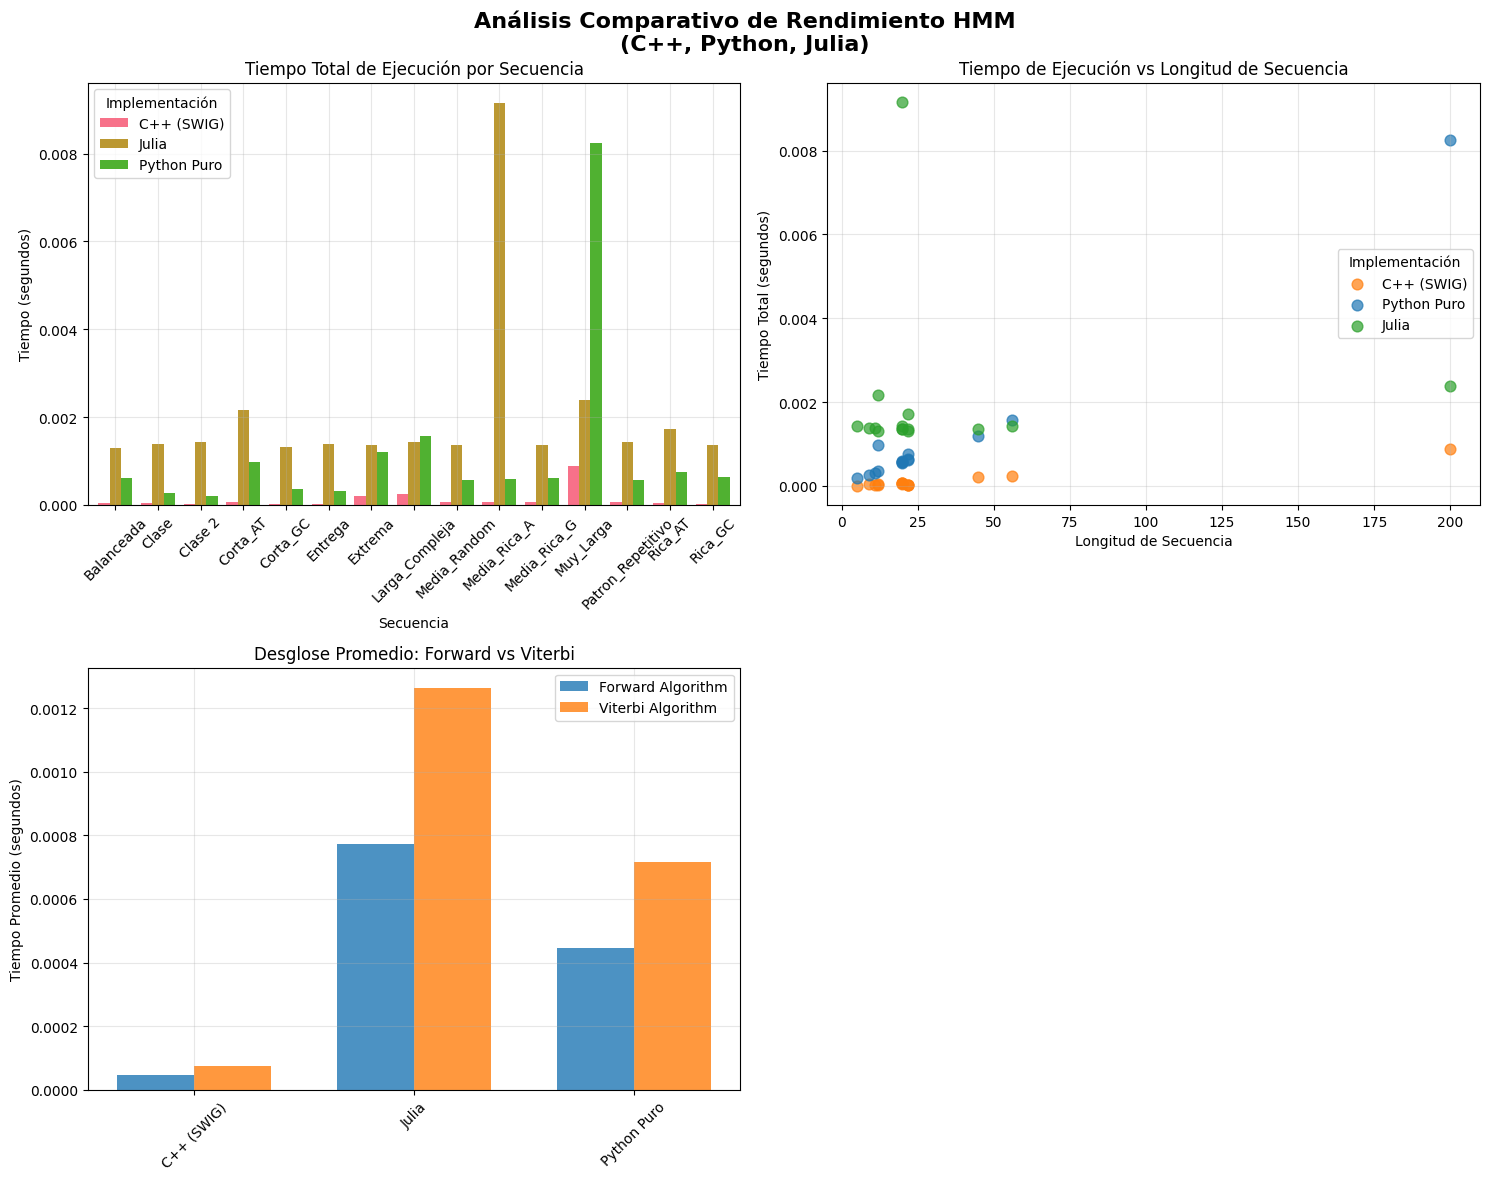

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

plt.style.use('default')
sns.set_palette("husl")

def create_performance_charts(results_dict):
    # Preparar datos para visualización
    data_for_plot = []

    for name, data in results_dict.items():
        data_for_plot.extend([
            {'Secuencia': name, 'Longitud': len(data['sequence']),
             'Implementación': 'C++ (SWIG)', 'Tiempo_Total': data['swig']['total_time'],
             'Tiempo_Forward': data['swig']['forward_time'], 'Tiempo_Viterbi': data['swig']['viterbi_time']},
            {'Secuencia': name, 'Longitud': len(data['sequence']),
             'Implementación': 'Python Puro', 'Tiempo_Total': data['python']['total_time'],
             'Tiempo_Forward': data['python']['forward_time'], 'Tiempo_Viterbi': data['python']['viterbi_time']},
            {'Secuencia': name, 'Longitud': len(data['sequence']),
             'Implementación': 'Julia', 'Tiempo_Total': data['julia']['total_time'],
             'Tiempo_Forward': data['julia']['forward_time'], 'Tiempo_Viterbi': data['julia']['viterbi_time']}
        ])

    df = pd.DataFrame(data_for_plot)

    # Crear figura con 3 subplots (quitamos aceleración)
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Análisis Comparativo de Rendimiento HMM\n(C++, Python, Julia)',
                 fontsize=16, fontweight='bold')

    # Tiempo total por secuencia
    ax1 = axes[0, 0]
    df_pivot = df.pivot(index='Secuencia', columns='Implementación', values='Tiempo_Total')
    df_pivot.plot(kind='bar', ax=ax1, width=0.8)
    ax1.set_title('Tiempo Total de Ejecución por Secuencia')
    ax1.set_ylabel('Tiempo (segundos)')
    ax1.tick_params(axis='x', rotation=45)
    ax1.legend(title='Implementación')
    ax1.grid(True, alpha=0.3)

    # Tiempo vs longitud de secuencia
    ax2 = axes[0, 1]
    colors = {'C++ (SWIG)': '#ff7f0e', 'Python Puro': '#1f77b4', 'Julia': '#2ca02c'}
    for impl in df['Implementación'].unique():
        impl_data = df[df['Implementación'] == impl]
        ax2.scatter(impl_data['Longitud'], impl_data['Tiempo_Total'],
                    label=impl, s=60, alpha=0.7, color=colors.get(impl, '#d62728'))
    ax2.set_title('Tiempo de Ejecución vs Longitud de Secuencia')
    ax2.set_xlabel('Longitud de Secuencia')
    ax2.set_ylabel('Tiempo Total (segundos)')
    ax2.legend(title='Implementación')
    ax2.grid(True, alpha=0.3)

    # Desglose de tiempos (Forward vs Viterbi)
    ax3 = axes[1, 0]
    avg_times = df.groupby('Implementación')[['Tiempo_Forward', 'Tiempo_Viterbi']].mean()

    x = np.arange(len(avg_times.index))
    width = 0.35

    ax3.bar(x - width/2, avg_times['Tiempo_Forward'], width,
            label='Forward Algorithm', alpha=0.8, color='#1f77b4')
    ax3.bar(x + width/2, avg_times['Tiempo_Viterbi'], width,
            label='Viterbi Algorithm', alpha=0.8, color='#ff7f0e')

    ax3.set_title('Desglose Promedio: Forward vs Viterbi')
    ax3.set_ylabel('Tiempo Promedio (segundos)')
    ax3.set_xticks(x)
    ax3.set_xticklabels(avg_times.index, rotation=45)
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    # Eliminar el subplot vacío (axes[1,1]) para que no quede hueco
    fig.delaxes(axes[1, 1])

    plt.tight_layout()
    plt.show()

    return df
performance_df = create_performance_charts(batch_results)

